Insurance dataset is a data set about predicting the amount of insurance to pay for a patient, which includes the following features:
- age: Age of the patient, is a positive integer value
- sex: Patient's gender where 0 is male, 1 is female
- bmi: The patient's BMI, is the actual value
- children: Number of children of the patient, is a positive integer value
- smoker: Indicates whether the patient smokes, where 1 is yes and 0 is no
- region: Indicate the region the patient is in, 0 is southwest 1 is southeast 2 is northwest and 3 is northeast

- charges: Individual medical costs billed by health insurance.

In [1]:
#import library
import pandas as pd # pandas
import numpy as np # numpy
import time


In [2]:
#Download Dataset
# !wget https://raw.githubusercontent.com/huynhthanh98/data__/refs/heads/main/Insurance.csv

In [3]:
# !gdown 1sLbhw9Oevzg5Z35ZZtpTygi9ASDOw4sZ

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

# Prepare and Analyze Data

1. Load Dataset
2. Analyze Dataset
3. Preprocess data (type, null, missing, ...)
4. Feature Engineering

## Load Dataset

When loading datasets with `pd.read_csv`, you should be aware of several important parameters:

*   `filepath_or_buffer`: The path to the CSV file.
*   `sep`: The delimiter used in the CSV file (e.g., ',' for comma-separated, '\t' for tab-separated). Default is ','.
*   `header`: Row number(s) to use as the column names. Default is 0 (the first row).
*   `index_col`: Column(s) to use as the row labels of the DataFrame. Can be a column name or column index.
*   `na_values`: Additional strings to recognize as `NaN` (Not a Number).
*   `dtype`: Dictionary specifying column data types (e.g., `{'col_name': 'int64'}`).
*   `parse_dates`: List of column names to parse as dates.

In [5]:
# /content/drive/MyDrive/Bộ Môn/Giảng Dạy/2025-2026/NMMH/lab01/Insurance.csv

In [6]:
# read data using Pandas DataFrame
def read_dataset(path):
    # read data using Pandas DataFrame
    df = pd.read_csv(path)
    display(df.head())
    print("\nDataFrame Info:")
    print(df.info())
    print("\nDataFrame Shape:", df.shape)
    display(df.describe())
    return df

In [7]:
df = read_dataset(r"D:\ML\tuan1\Insurance.csv")

,age,sex,bmi,children,smoker,region,charges
0,43,female,25.800,0,yes,northwest,31128.291496
1,43,female,28.600,2,no,southwest,8739.200017
2,34,female,37.290,4,no,northeast,10979.246131
3,50,female,42.370,3,no,southeast,15278.753423
4,26,female,29.595,1,no,northeast,5153.591905



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59333 entries, 0 to 59332
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       59333 non-null  int64  
 1   sex       59333 non-null  object 
 2   bmi       59333 non-null  float64
 3   children  59333 non-null  int64  
 4   smoker    59333 non-null  object 
 5   region    59333 non-null  object 
 6   charges   59333 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 3.2+ MB
None

DataFrame Shape: (59333, 7)


,age,bmi,children,charges
count,59333.000000,59333.000000,59333.000000,59333.000000
mean,40.791448,30.930536,1.107411,13459.312130
std,13.897712,6.121275,1.455713,10175.464573
min,18.000000,15.815000,-1.000000,0.375242
25%,28.000000,26.510000,0.000000,6449.205453
50%,42.000000,30.600000,1.000000,10570.434369
75%,52.000000,35.000000,2.000000,15058.323202
max,65.000000,54.130000,6.000000,63770.428010


## Data Analysis

### 1. Checking for Missing Data
It is essential to check for null values before modeling. We use `.isnull().sum()` to identify any columns that require data imputation.

In [8]:
# Check for missing values in the dataset
print("Missing values summary:")
display(df.isnull().sum())

Missing values summary:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### 2. Distribution of Target Variable
We visualize the distribution of `charges` to understand its spread and identify if there is a significant skew, which might affect linear regression performance.

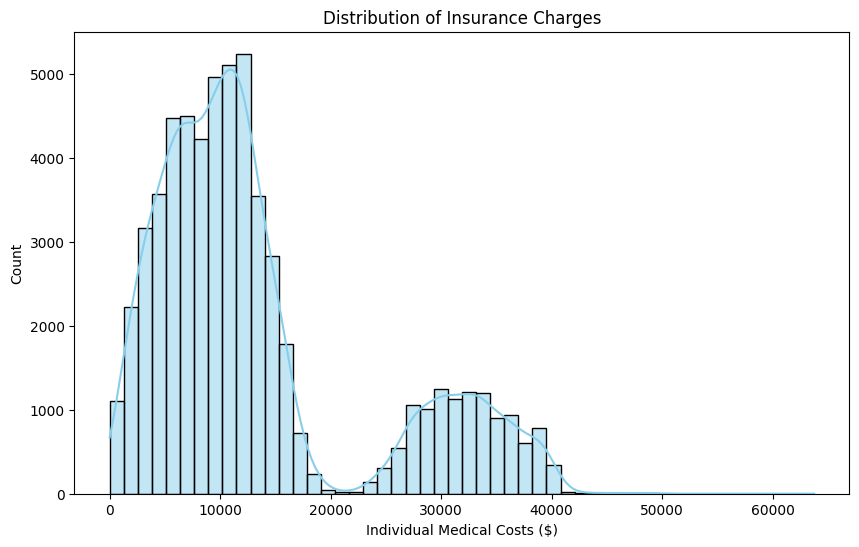

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Individual Medical Costs ($)')
plt.ylabel('Count')
plt.show()

### 3. Analyzing Categorical Features
Boxplots are excellent for teaching students how binary or categorical features (like smoking status) impact the target variable.

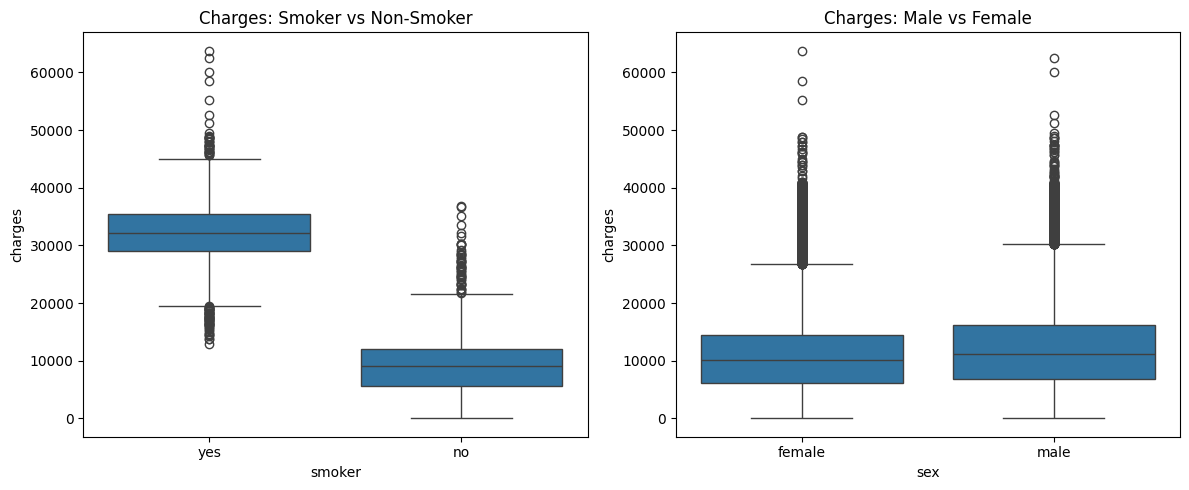

In [10]:
# Comparative analysis using boxplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges: Smoker vs Non-Smoker')

plt.subplot(1, 2, 2)
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Charges: Male vs Female')

plt.tight_layout()
plt.show()

<Axes: xlabel='charges', ylabel='Count'>

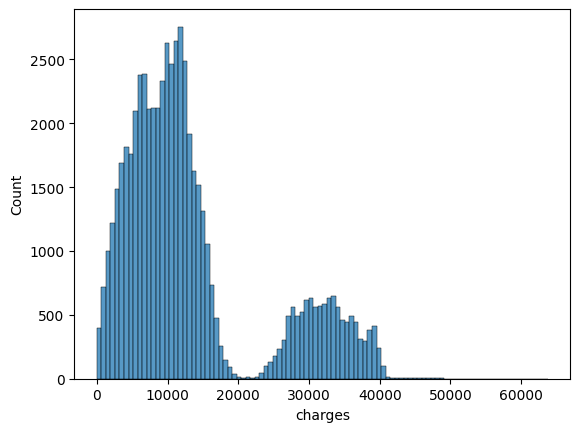

In [11]:
import seaborn as sns
sns.histplot(x="charges", data=df, bins=100)

## Preprocessing

In [12]:
# --- (Optional) Drop null datapoints or fill missing data
# print("Sample size:", len(df))
# df = df.dropna() <=> df.dropna(inplace=True)
# df = df.dropna()
# print("Not null sample size:", len(df))

In [13]:
def preprocessing_data(df):
    # --- (Optional) Drop null datapoints or fill missing data
    # Keep your data the same if you dont want to customize it
    df = df
    return df

In [14]:
df = preprocessing_data(df.copy())

## Feature Engineering

In [15]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,43,female,25.800,0,yes,northwest,31128.291496
1,43,female,28.600,2,no,southwest,8739.200017
2,34,female,37.290,4,no,northeast,10979.246131
3,50,female,42.370,3,no,southeast,15278.753423
4,26,female,29.595,1,no,northeast,5153.591905


In [16]:
def normalize_data(df):
    # data normalization
    normalized_data = df.copy()
    normalized_data["sex"] = normalized_data["sex"].astype("category").cat.codes
    normalized_data["smoker"] = normalized_data["smoker"].astype("category").cat.codes
    normalized_data["region"] = normalized_data["region"].astype("category").cat.codes

    display(normalized_data.head())
    display(normalized_data.corr())
    return normalized_data


,age,sex,bmi,children,smoker,region,charges
0,43,0,25.800,0,1,1,31128.291496
1,43,0,28.600,2,0,3,8739.200017
2,34,0,37.290,4,0,0,10979.246131
3,50,0,42.370,3,0,2,15278.753423
4,26,0,29.595,1,0,0,5153.591905


,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.004123,0.091252,0.008060,-0.029931,0.007996,0.331857
sex,-0.004123,1.000000,0.049948,0.017484,0.080734,0.015634,0.084363
bmi,0.091252,0.049948,1.000000,0.030296,0.002000,0.149486,0.202631
children,0.008060,0.017484,0.030296,1.000000,0.002852,0.021358,0.087100
smoker,-0.029931,0.080734,0.002000,0.002852,1.000000,0.031686,0.909658
region,0.007996,0.015634,0.149486,0.021358,0.031686,1.000000,0.024945
charges,0.331857,0.084363,0.202631,0.087100,0.909658,0.024945,1.000000


<Axes: >

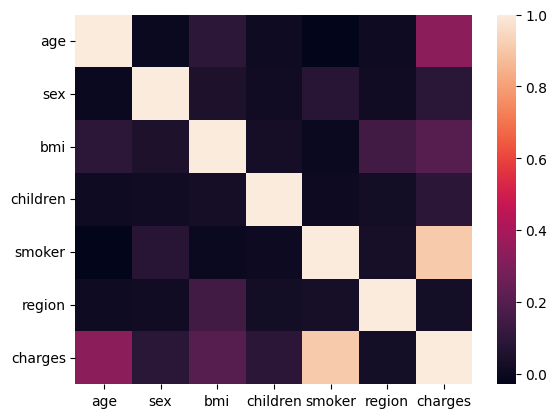

In [17]:
# Heatmap
import seaborn as sns

normalized_data = normalize_data(df)
sns.heatmap(normalized_data.corr())

# Apply machine learning model

## Train-test split

In [18]:
columns = df.columns.tolist()
columns


['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [19]:
def prepare_X_y(df):
    ## Split X, y from dataset
    columns = df.columns.tolist()     # Columns name
    columns.remove('charges')           # Remove y label (column charges in this case)
    # columns = ["smoker_yes", "bmi", "age"]
    X = df[columns]        # X
    y = df.charges          # y
    return X, y

X, y = prepare_X_y(normalized_data)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error



def split_train_test(X, y, train_size=0.7):
    trainX, testX ,trainY, testY = train_test_split(X, y, train_size=train_size, random_state=2023)
    print('Training:' + str(trainX.shape))
    print('Test:' + str(testX.shape))

    return trainX, testX ,trainY, testY

trainX, testX ,trainY, testY = split_train_test(X, y)

Training:(41533, 6)
Test:(17800, 6)


## Basic Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression


def build_linear_model(X, y):
    model = LinearRegression(fit_intercept=True)
    model.fit(trainX, trainY)

    return model

model = build_linear_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(trainX)
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY) )
pred = model.predict(testX)
print("mean absolute error of linear model on test set ", mean_absolute_error(y_pred=pred, y_true=testY) )

print(model.coef_) # print coefficient
print()
print(model.intercept_) # print intercept_


mean absolute error of linear model on train set  100.2004657160054
mean absolute error of linear model on test set  97.05605617712011
[  251.5138989     37.66451724   285.95725561   541.05605803
 23646.11182404  -317.42447355]

-10384.58663078299


## Polynomial Transform

When the data feature does not conform to a linear function, a linear regression cannot be applied directly to the original data. Then, there are many possibilities that the data feature conforms to the polynomial function. Scikit-Learn supports converting data features to polynomials through ``PolynomialFeatures``.

$$
y = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + \cdots
$$

The formula above uses the transformation of the value $x$ from one dimension to the other, with the aim of being able to use linear regression to find complex relationships between $x$ and $y$.

In [22]:
#Linear Regression with Polynomial Transform
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def build_pipeline(X, y):
    poly_model = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
    poly_model.fit(X, y)

    return poly_model

poly_model = build_pipeline(trainX, trainY)
# Compare on training dataset
poly_pred = poly_model.predict(trainX)
print("mean absolute error of linear model (with poly transform) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY) )

poly_pred = poly_model.predict(testX)
print("mean absolute error of linear model (with poly transform) on test set ", mean_absolute_error(y_pred=poly_pred, y_true=testY))

mean absolute error of linear model (with poly transform) on train set  143.56015930798793
mean absolute error of linear model (with poly transform) on test set  140.2486899874257


degree of PolynomialFeatures function is defined by a tuple (x, y) where x is the smallest degree, y is the largest degree, if we only input 1 value t, the function will understand x = 0 and y = t

> Indented block
* if the 2nd order with 1 feature is $X_1$ then the equation is of the form:
$$\theta_0 + \theta_1*X_1+\theta_2*X_1^2$$
* if the 2nd order with 2 features is $X_1$ and $X_2$ then the equation is of the form:
$$\theta_0 + \theta_1*X_1+\theta_2*X_2+\theta_3*X_1^2 + \theta_4*X_2^2 + \theta_5*X_1*X_2$$

In [23]:
# --- To get output of polynomial model
# We can call its name
linear_model = poly_model["linearregression"]
# or by number
linear_model = poly_model[1]

In [24]:
linear_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#Exercise
This is a dataset related to how much money a person can get from a mortgage on his or her home. This dataset includes the following features:
* Gender: Gender of the borrower (including two values 'F' and 'M')
* Age: Age of the customer applying for a loan (including positive integer values)
* Income (USD): Customer's income in USD (value is a positive number)
* Income Stability: The level of customer's income stability (including three values of Low and High)
* Property Age: Life expectancy of the house in days (including positive integer values)
* Property Location: Location of the house (including 'Rural', 'Urban', and 'Semi-Urban')
* Property Price: The value of the house in USD (including positive real values)
* Loan Sanction Amount (USD): Amount that customers can borrow in USD (target value)

Based on practice sample #1, proceed:
1. Read data
2. Visualize some information of data
3. Normalize Data (Feature Engineering) to train linear regression model
4. Train linear regression model and show the model's intercepts, coeficients
5. Learn on sklearn how to use Ridge, Lasso, and ElasticNet compare the error of all 3 algorithms with Linear Regression (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
6. Let's try Polynomial of order 2 to compare the previous results. What will the result be if we choose the n order too high?


**Submission Link**: https://forms.gle/uKAq34QrbwTcbs5Z9 (Submit your .ipynb file)

In [25]:
#Load dữ liệu
df = read_dataset(r"D:\ML\tuan1\final_house_loan.csv")

,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
0,F,19,1641.25,Low,1651.25,Rural,59641.82,21026.420753
1,M,29,1989.71,Low,1990.71,Urban,179858.51,60595.183366
2,F,37,1849.91,Low,1856.91,Rural,117297.62,39181.648002
3,M,65,2735.18,High,2747.18,Rural,354417.72,128497.710865
4,F,62,4741.78,High,4740.78,Urban,82049.80,39386.919336



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47297 entries, 0 to 47296
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      47297 non-null  object 
 1   Age                         47297 non-null  int64  
 2   Income (USD)                47265 non-null  float64
 3   Income Stability            47285 non-null  object 
 4   Property Age                47263 non-null  float64
 5   Property Location           47294 non-null  object 
 6   Property Price              47297 non-null  float64
 7   Loan Sanction Amount (USD)  47297 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.9+ MB
None

DataFrame Shape: (47297, 8)


,Age,Income (USD),Property Age,Property Price,Loan Sanction Amount (USD)
count,47297.000000,47265.000000,47263.000000,4.729700e+04,47297.000000
mean,40.000063,2586.684384,2586.611058,1.350880e+05,46487.229765
std,16.086128,1558.768809,1558.842286,9.457875e+04,32549.905634
min,18.000000,372.700000,370.700000,7.859620e+03,254.586578
25%,24.000000,1653.740000,1652.820000,6.250408e+04,21782.822159
50%,40.000000,2245.480000,2244.810000,1.130936e+05,38822.132402
75%,55.000000,3128.560000,3128.380000,1.819546e+05,62612.236905
max,65.000000,54662.750000,54647.750000,1.077967e+06,366131.165218


<Figure size 1200x500 with 0 Axes>

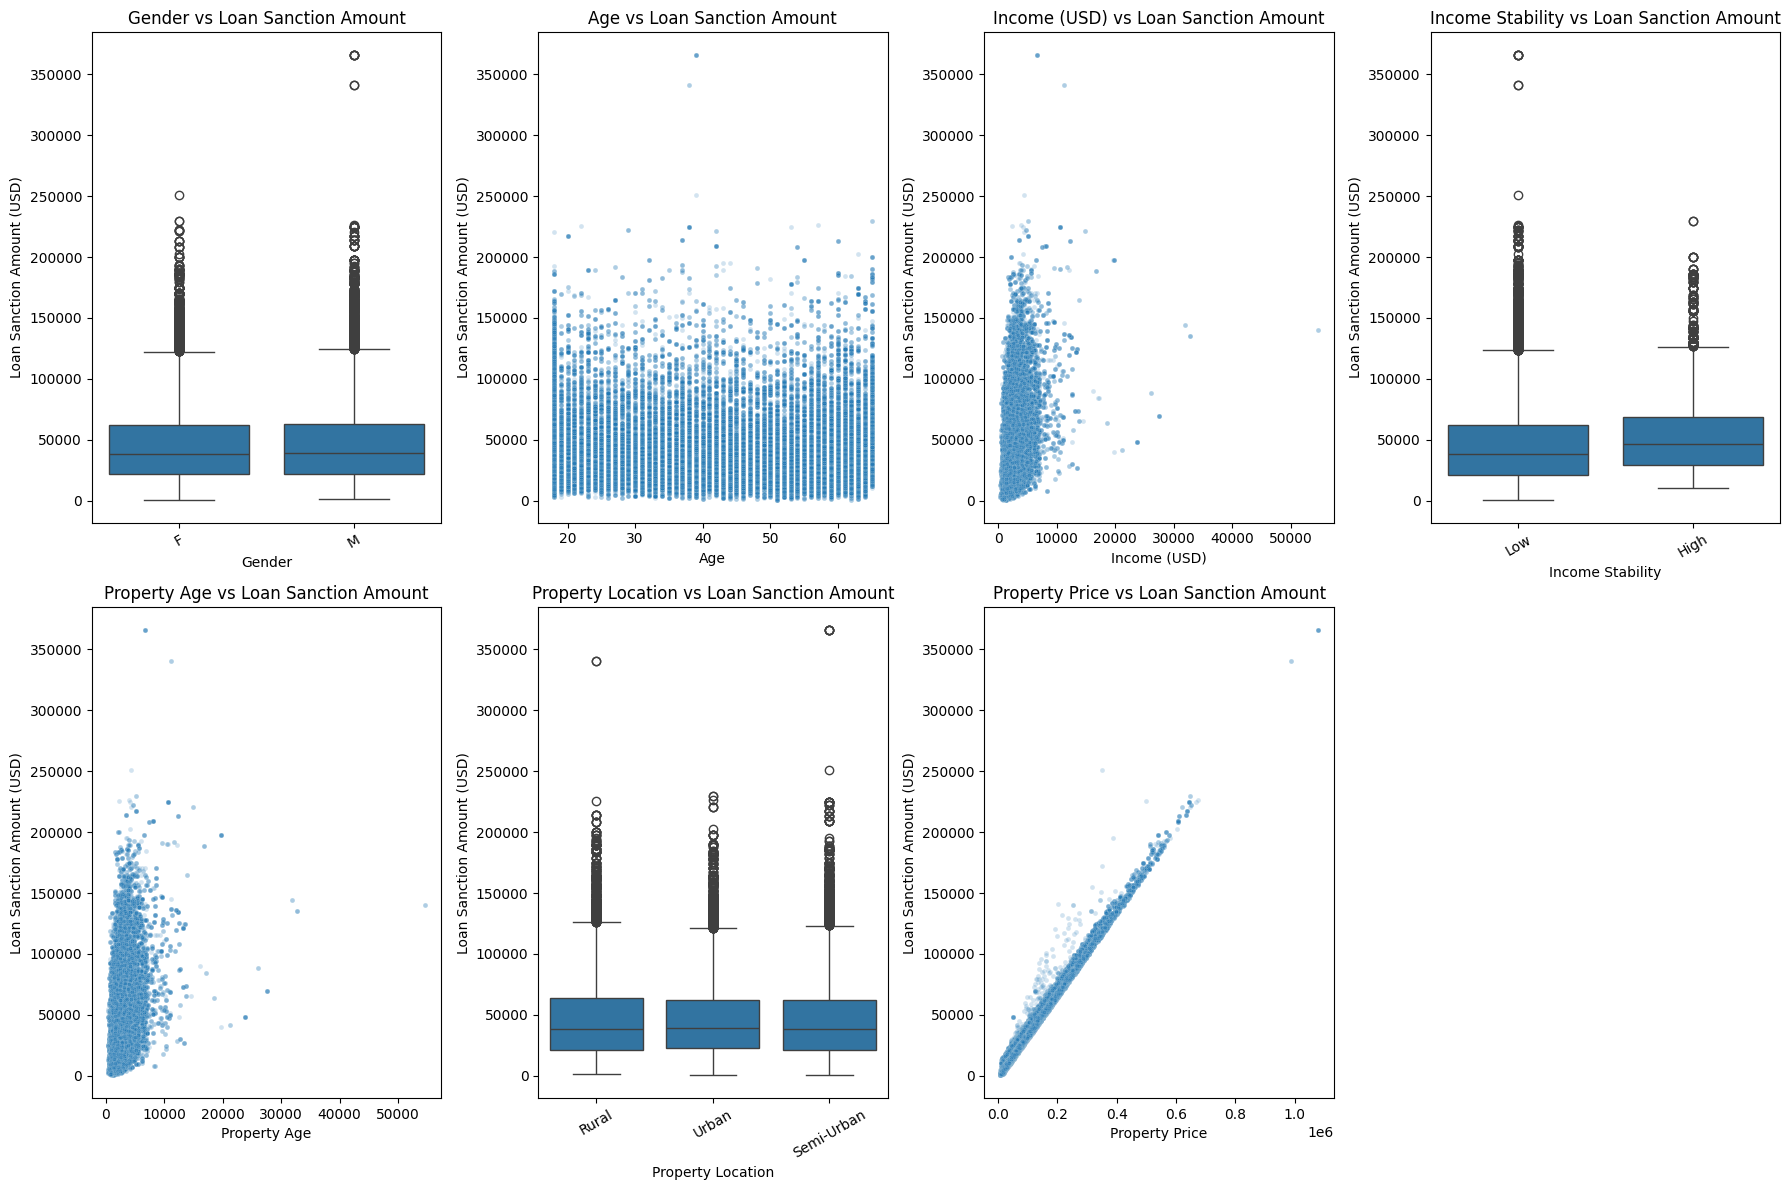

In [44]:
#visualize data
X = df.drop(columns=["Loan Sanction Amount (USD)"])
y = df["Loan Sanction Amount (USD)"]

plt.figure(figsize=(12, 5))
plt.figure(figsize=(18, 4 * 3))

for i, col in enumerate(X.columns, 1):
    plt.subplot(2, 4, i)

    if pd.api.types.is_numeric_dtype(X[col]):
        sns.scatterplot(x=X[col], y=y, alpha=0.2, s=12)
    else:
        sns.boxplot(x=X[col], y=y)
        plt.xticks(rotation=30)

    plt.title(f"{col} vs Loan Sanction Amount")
    plt.xlabel(col)
    plt.ylabel("Loan Sanction Amount (USD)")

plt.tight_layout()
plt.show()

In [33]:
#Kiểm tra các giá trị missing
print("Missing values summary:")
display(df.isnull().sum())

Missing values summary:


Gender                         0
Age                            0
Income (USD)                  32
Income Stability              12
Property Age                  34
Property Location              3
Property Price                 0
Loan Sanction Amount (USD)     0
dtype: int64

In [34]:
#làm đầy các giá trị missing các cột có giá trị bằng giá trị trung bình cột
df['Income (USD)'].fillna(df['Income (USD)'].mean(), inplace=True)
df['Property Age'].fillna(df['Property Age'].mean(), inplace=True)

#làm đầy các giá trị missing các cột có chữ bằng giá trị phổ biến nhất cột
df['Income Stability'].fillna(df['Income Stability'].mode()[0], inplace=True)
df['Property Location'].fillna(df['Property Location'].mode()[0], inplace=True)

C:\Users\quanp\AppData\Local\Temp\ipykernel_17412\2219238881.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income (USD)'].fillna(df['Income (USD)'].mean(), inplace=True)
C:\Users\quanp\AppData\Local\Temp\ipykernel_17412\2219238881.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [35]:
# Kiểm tra lại các giá trị missing
print("Missing values summary:")
display(df.isnull().sum())

Missing values summary:


Gender                        0
Age                           0
Income (USD)                  0
Income Stability              0
Property Age                  0
Property Location             0
Property Price                0
Loan Sanction Amount (USD)    0
dtype: int64

In [36]:
# Chuẩn hóa các cột Age, Income (USD), Property Age, Property Price 
df1 = df.drop(['Gender', 'Income Stability', 'Property Location', 'Loan Sanction Amount (USD)'], axis=1)
array = df1.values
# sử dụng phương pháp minmax
from sklearn import preprocessing

###scale dữ liệu bằng phương pháp minmax
scaler = preprocessing.MinMaxScaler()
minmax = scaler.fit_transform(array)
minmax_df = pd.DataFrame(minmax, columns=df1.columns)
print('Scaling du lieu:\n', minmax_df)

Scaling du lieu:
             Age  Income (USD)  Property Age  Property Price
0      0.021277      0.023366      0.023593        0.048390
1      0.234043      0.029785      0.029847        0.160731
2      0.404255      0.027210      0.027382        0.102268
3      1.000000      0.043516      0.043784        0.323854
4      0.936170      0.080477      0.080514        0.069330
...         ...           ...           ...             ...
47292  0.936170      0.032212      0.032514        0.217204
47293  0.425532      0.020888      0.020912        0.196776
47294  0.042553      0.022516      0.022319        0.136995
47295  0.680851      0.030016      0.030152        0.060198
47296  0.595745      0.002214      0.002344        0.015641

[47297 rows x 4 columns]


In [37]:
# Sử dụng các cột còn lại thành 1 df mới
df2 = df[['Gender', 'Income Stability', 'Property Location']]
df2 = pd.get_dummies(df2, drop_first=True)
df2

,Gender_M,Income Stability_Low,Property Location_Semi-Urban,Property Location_Urban
0,False,True,False,False
1,True,True,False,True
2,False,True,False,False
3,True,False,False,False
4,False,False,False,True
...,...,...,...,...
47292,False,True,False,False
47293,True,True,False,False
47294,False,True,True,False
47295,False,True,True,False


In [38]:
# chuẩn bị X, y trong đó X là df ghép từ 2 df trên
# y là cột Loan Sanction Amount (USD)
X = pd.concat([minmax_df, df2], axis=1)
y = df['Loan Sanction Amount (USD)']

In [39]:
#Chia tập train/test
trainX, testX ,trainY, testY = train_test_split(X, y, train_size=0.7, random_state= 2023)
print('Training: ' + str(trainX.shape))
print('Test: ' + str(testX.shape))

Training: (33107, 8)
Test: (14190, 8)


In [40]:
#Chạy linear 
model = build_linear_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(trainX)
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY) )
pred = model.predict(testX)
print("mean absolute error of linear model on test set ", mean_absolute_error(y_pred=pred, y_true=testY) )

print(model.coef_) # print coefficient
print()
print(model.intercept_) # print intercept_

mean absolute error of linear model on train set  223.81411058697523
mean absolute error of linear model on test set  213.89758330371322
[-3.74543624e+03  1.02638942e+06 -9.70588843e+05  3.59950009e+05
 -2.38997909e+02 -1.11371328e+04 -2.85476349e+02 -1.18649493e+02]

13618.584259836745


In [41]:
#So sánh các model
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),        # alpha là siêu tham số kiểm soát mức độ phạt
    "Lasso Regression": Lasso(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5) 
}

results = []
for name, model in models.items():
    # Huấn luyện
    model.fit(trainX, trainY)
    
    pred = model.predict(testX)
    
    # Tính các độ đo lỗi
    mae = mean_absolute_error(testY, pred)
    mse = mean_squared_error(testY, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(testY, pred)
    
    # Lưu kết quả
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2-score': r2
    })

print(pd.DataFrame(results).set_index('Model'))

                            MAE           MSE          RMSE  R2-score
Model                                                                
Linear Regression    213.897583  2.081707e+06   1442.812286  0.998019
Ridge Regression     172.035272  2.065533e+06   1437.196253  0.998035
Lasso Regression     154.732883  2.060208e+06   1435.342497  0.998040
ElasticNet         24564.758422  1.016847e+09  31888.038947  0.032477


In [42]:
def build_pipeline(X, y):
    poly_model = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
    poly_model.fit(X, y)

    return poly_model

poly_model = build_pipeline(trainX, trainY)
# Compare on training dataset
poly_pred = poly_model.predict(trainX)
print("mean absolute error of linear model (with poly transform) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY) )

poly_pred = poly_model.predict(testX)
print("mean absolute error of linear model (with poly transform) on test set ", mean_absolute_error(y_pred=poly_pred, y_true=testY))


mean absolute error of linear model (with poly transform) on train set  181.46154995397245
mean absolute error of linear model (with poly transform) on test set  169.95385108382033


If we choose the n order too high, the model will suffer from Overfitting. The model becomes overly complex, capturing noise and outliers in the training data (High Variance). As a result, the training error will be very low, but the testing error will increase significantly because the model fails to generalize to unseen data. Additionally, it leads to a huge computational cost due to the massive increase in the number of generated features.